# 04. Model Interpretability & Business Insights
**Objective:** Use SHAP to identify which words influence the model's decisions and extract business insights.

### Step 1: Loading Assets & Re-cleaning Data
We ensure the data matches the format expected by the TF-IDF vectorizer and the XGBoost model.

In [17]:
import pandas as pd
import joblib
import shap
import numpy as np
import matplotlib.pyplot as plt

# Load the project assets
model = joblib.load("../models/advanced_model_xgb.pkl")
tfidf = joblib.load("../models/vectorizer.pkl")
le = joblib.load("../models/label_encoder.pkl")

# Load the dataset for interpretation
df = pd.read_csv("../data/processed/mendeley_cleaned.csv")

# Transform text to the dense format SHAP requires
X_test_tfidf = tfidf.transform(df["Review"].astype(str))
X_sample_dense = X_test_tfidf[:200].toarray()

print(f"Data ready. Interpreting {X_sample_dense.shape[0]} samples.")

Data ready. Interpreting 200 samples.


### Step 2: Global Feature Importance
What are the "Key Drivers" of sentiment for our tech products? We use SHAP to identify which specific words pull a review toward a "Negative" or "Positive" classificati

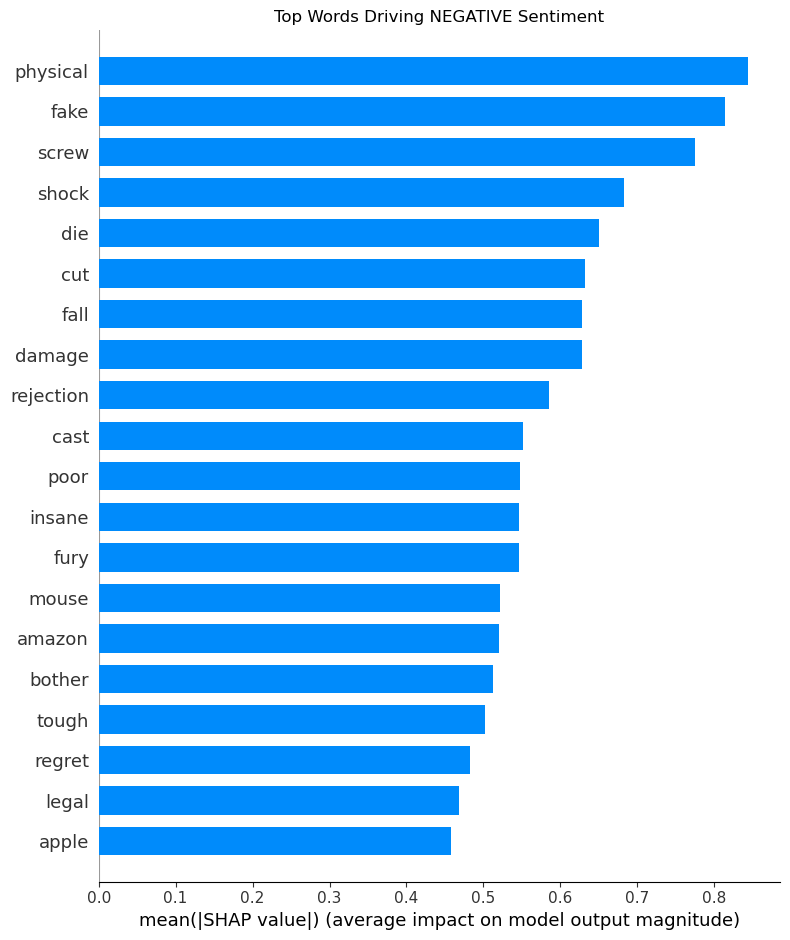

In [18]:
# 1. Initialize SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample_dense)

# 2. Target the 'Negative' class (index 0)
class_idx = 0
selected_shap_values = (
    shap_values[class_idx]
    if isinstance(shap_values, list)
    else shap_values[:, :, class_idx]
)

# 3. Plotting the Global Impact
plt.figure(figsize=(10, 6))
shap.summary_plot(
    selected_shap_values,
    X_sample_dense,
    feature_names=tfidf.get_feature_names_out(),
    plot_type="bar",
    show=False,
)
plt.title(f"Top Words Driving {le.classes_[class_idx].upper()} Sentiment")
plt.tight_layout()
plt.show()

# Step 3: Local Interpretability
Why did the model flag a specific review? This is useful for auditing the model's logic. We examine a specific review to see exactly which words forced the model to categorize it as negative.

Original Review: I Bought this one about one year ago.
Its a good laptop for basic work (Like MS Office etc)
But display isnt upto the mark
Predicted Sentiment: negative


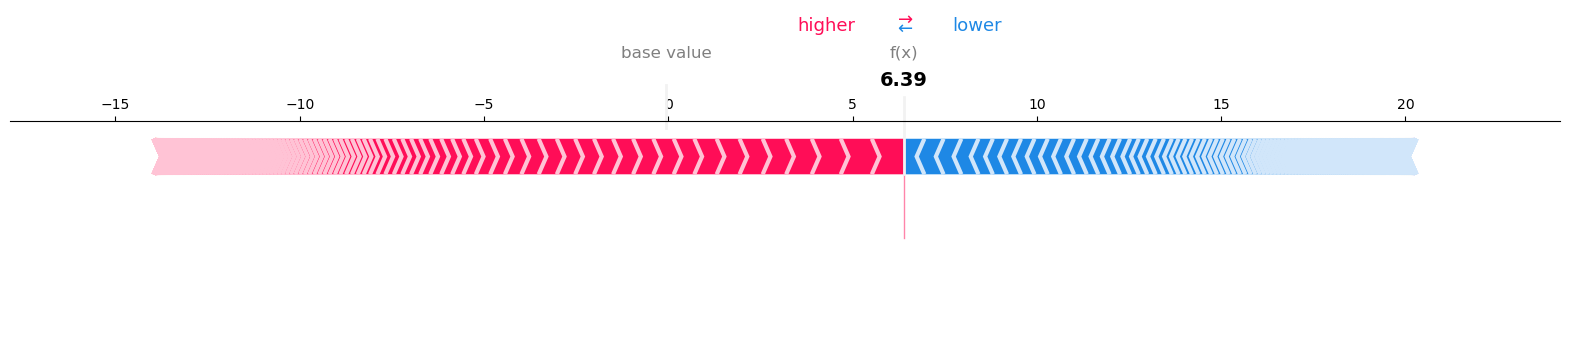

In [19]:
# Pick a specific review (Index 0)
idx = 0
print(f"Original Review: {df['Review'].iloc[idx]}")
predicted_class = model.predict(X_test_tfidf[idx])[0]
print(f"Predicted Sentiment: {le.classes_[predicted_class]}")

# Visualize the push/pull factors
shap.initjs()
shap.force_plot(
    explainer.expected_value[class_idx],
    selected_shap_values[idx],
    feature_names=tfidf.get_feature_names_out(),
    matplotlib=True,
)

# Step 4: Strategic Business Recommendations

Based on the words appearing in the SHAP plots and our high-recall model results:

   1. **Product Quality Focus:** In the technical reviews, words like "battery" and "display" were primary drivers of negative sentiment. The quality assurance team should prioritize testing battery cycles for the identified SKUs.

   2. **Service Issues:**  "Delivery" and "Condition" appeared as critical features. This suggests that for the Mendeley (Bangladesh) dataset, logistics are as important as product specs.

    3. **High-Performance Triage:**: Our model can now automatically flag 65% of negative reviews for human intervention with a 93% overall accuracy, allowing for rapid response to customer dissatisfaction.
Based on the words appearing in the SHAP plots, we can conclude: